Nova Retail | Customer Behavior & Business Insights


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [14]:

df = pd.read_csv('/content/sample_data/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


Descripción de los datos

El dataset contiene información demográfica, de comportamiento y de valor comercial de los clientes de Nova Retail.

Variable	Descripción
id_cliente	Identificador único del cliente
edad	Edad del cliente
nivel_ingreso	Ingreso anual estimado del cliente
visitas_mes	Visitas mensuales a la plataforma
compras_mes	Compras realizadas durante el mes
gasto_publicidad_dirigida	Inversión publicitaria asignada al cliente
satisfaccion	Nivel de satisfacción (1–5)
miembro_premium	Membresía Premium: 1 = sí, 0 = no
abandono	Estado de abandono: 1 = abandonó, 0 = activo
tipo_dispositivo	Móvil, escritorio o tablet
region	Región geográfica del cliente
ingreso_anual	Ingreso anual generado por el cliente para Nova Retail

Métrica principal: ingreso_anual se utiliza como indicador del valor económico generado por cada cliente.

In [15]:
df.head()


,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


Exploración inicial de los datos

El conjunto de datos contiene 15,000 registros y 12 columnas, sin valores nulos.

La revisión inicial permitió identificar tres tipos principales de variables:

Numéricas: edad, nivel_ingreso, visitas_mes, compras_mes, gasto_publicidad_dirigida, satisfaccion e ingreso_anual.
Binarias: miembro_premium y abandono, ambas correctamente codificadas como 0 y 1.
Categóricas: tipo_dispositivo y region.
Identificador: id_cliente, utilizado únicamente para identificar cada cliente y no como variable analítica.

Los tipos de datos son adecuados en general. Sin embargo, edad está almacenada como float, aunque representa valores enteros, por lo que se convertirá a tipo int.

Conclusión: el dataset presenta una estructura consistente y no contiene valores faltantes. La principal corrección inicial corresponde al tipo de dato de edad, antes de continuar con el análisis exploratorio.

In [16]:
df['edad'] = df['edad'].astype(int)


In [17]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


In [18]:
df.describe()


,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


Diagnóstico inicial de variables numéricas

El análisis descriptivo inicial permite identificar patrones relevantes en el perfil y comportamiento de los clientes:

edad: los clientes tienen una edad promedio cercana a 38 años, con un rango entre 18 y 75 años. La cercanía entre media y mediana sugiere una distribución relativamente equilibrada.
nivel_ingreso: presenta un promedio cercano a 30,000 y un rango aproximado de 8,000 a 74,790. La variabilidad observada indica diferencias económicas entre los clientes que podrían ser útiles para posteriores análisis de segmentación.
visitas_mes: los usuarios realizan alrededor de 10 visitas mensuales en promedio, con un máximo de 25.
compras_mes: el promedio es de aproximadamente 1.2 compras mensuales, con una mediana de 1. Al menos el 25% de los clientes registra cero compras, lo que sugiere una posible brecha entre visitas y conversión que merece mayor análisis.
gasto_publicidad_dirigida: presenta variabilidad entre clientes, lo que permitirá evaluar posteriormente si existe alguna relación entre la inversión publicitaria y el comportamiento de compra.
satisfaccion: el promedio se sitúa alrededor de 3.6 sobre 5, indicando un nivel de satisfacción moderadamente positivo.
miembro_premium: aproximadamente 13.9% de los clientes pertenece al programa Premium, por lo que representa un segmento minoritario de la base de clientes.
abandono: aproximadamente 15% de los clientes registra abandono (churn). Esta variable será especialmente relevante para identificar posibles características asociadas con la pérdida de clientes.
ingreso_anual: presenta una dispersión considerable y valores máximos notablemente superiores al promedio, por lo que será necesario analizar su distribución y evaluar la presencia de posibles valores atípicos.
Insight inicial

Los primeros resultados sugieren tres áreas especialmente relevantes para el análisis: conversión de visitas en compras, comportamiento de clientes Premium y abandono de clientes. Estas variables pueden ayudar a identificar segmentos y oportunidades de negocio para Nova Retail.

In [19]:
df['miembro_premium'].unique()
df['abandono'].unique()


array([0, 1])

Diagnóstico de variables binarias
miembro_premium: variable binaria donde 0 representa clientes estándar y 1 identifica clientes Premium. Permitirá comparar patrones de compra, satisfacción y comportamiento entre ambos segmentos.
abandono: variable binaria donde 0 representa clientes activos y 1 clientes que abandonaron. Esta variable será clave para analizar posibles factores asociados con el churn.

Conclusión: ambas variables están correctamente codificadas y no requieren transformación inicial. Se utilizarán posteriormente para segmentar clientes y comparar comportamientos.

In [20]:

df['region'].nunique()


4

In [21]:

df['tipo_dispositivo'].value_counts()

df['region'].value_counts()
print(df['tipo_dispositivo'].value_counts())
print(df['region'].value_counts())

tipo_dispositivo
móvil         9818
escritorio    3720
tablet        1462
Name: count, dtype: int64
region
norte    4395
oeste    3810
sur      3726
este     3069
Name: count, dtype: int64


Diagnóstico inicial de variables categóricas
Tipo de dispositivo
Móvil: aproximadamente 65% de los clientes utiliza dispositivos móviles, convirtiéndolo en el principal canal de acceso.
Escritorio: representa cerca del 25% de los usuarios, manteniendo una participación relevante.
Tablet: concentra aproximadamente 10% de los usuarios, siendo el dispositivo menos utilizado.

Insight: la clara predominancia de dispositivos móviles sugiere que la experiencia móvil debería ser una prioridad en la estrategia digital de Nova Retail, sin descuidar la experiencia de escritorio.

Región
Norte: concentra la mayor proporción de clientes.
Este: presenta la menor participación.
En general, la distribución entre regiones es relativamente equilibrada y ninguna concentra una proporción extremadamente alta de la base de clientes.

Insight: la presencia de clientes en distintas regiones permite realizar comparaciones geográficas sin una concentración excesiva en una única zona. Las diferencias observadas pueden investigarse posteriormente junto con métricas como compras, ingresos, satisfacción y abandono.

Supuestos y enfoque estadístico

El análisis utiliza todo el conjunto de datos disponible después de verificar la calidad, consistencia y tipos de las variables.

Se seleccionan diferentes medidas de asociación según la naturaleza de las variables:

Pearson: para evaluar relaciones lineales entre variables numéricas.
Spearman: para evaluar relaciones monótonas y reducir la sensibilidad a supuestos de normalidad.
Correlación punto biserial: para analizar la relación entre una variable numérica y una variable binaria.
Cramér's V: para medir la asociación entre variables categóricas.

Consideración: las asociaciones identificadas permiten detectar patrones y relaciones relevantes para el negocio, pero no implican causalidad.

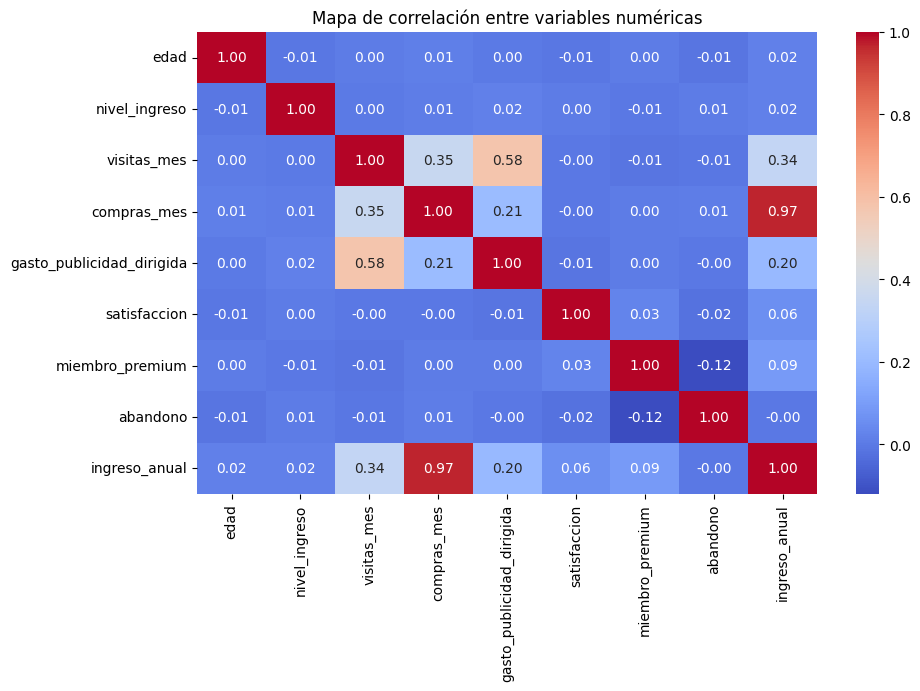

In [22]:
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Mapa de correlación entre variables numéricas')
plt.show()

Análisis de correlaciones

El mapa de correlación muestra algunas relaciones relevantes entre las variables de comportamiento:

compras_mes e ingreso_anual (r = 0.97): presentan una correlación positiva muy fuerte. Los clientes que realizan más compras también generan mayores ingresos anuales para el negocio, lo que destaca la frecuencia de compra como una métrica clave de valor del cliente.
visitas_mes y gasto_publicidad_dirigida (r = 0.58): muestran una correlación positiva moderada. Los clientes asociados con mayor inversión en publicidad dirigida también presentan una mayor frecuencia de visitas. Sin embargo, esta asociación no permite concluir que la publicidad sea la causa directa del aumento de visitas.
visitas_mes y compras_mes (r = 0.35): presentan una relación positiva moderada-baja. Una mayor frecuencia de visitas está asociada con más compras, aunque la relación no es suficientemente fuerte para explicar por sí sola el comportamiento de compra.
miembro_premium y abandono (r = -0.12): muestran una relación negativa débil. Los miembros Premium parecen presentar ligeramente menos abandono, pero la asociación es pequeña y requiere análisis adicional.
edad, nivel_ingreso y satisfaccion: no muestran relaciones lineales fuertes con las demás variables en este análisis inicial.
Insight de negocio

La relación más destacada es la existente entre frecuencia de compra e ingreso anual generado.

Insight de negocio: La frecuencia de compra aparece como uno de los indicadores más estrechamente asociados con el ingreso generado por cliente. Además, la relación entre publicidad dirigida y visitas merece mayor investigación para determinar si el aumento del tráfico se traduce posteriormente en compras e ingresos.

La relación entre publicidad dirigida y visitas también merece mayor investigación para determinar si el incremento del tráfico se traduce posteriormente en compras e ingresos.





### Scatterplot general


Análisis visual de las relaciones

Para complementar el análisis de correlación, se utiliza una matriz de scatterplots para observar visualmente la dirección, dispersión y posibles patrones entre las variables numéricas.

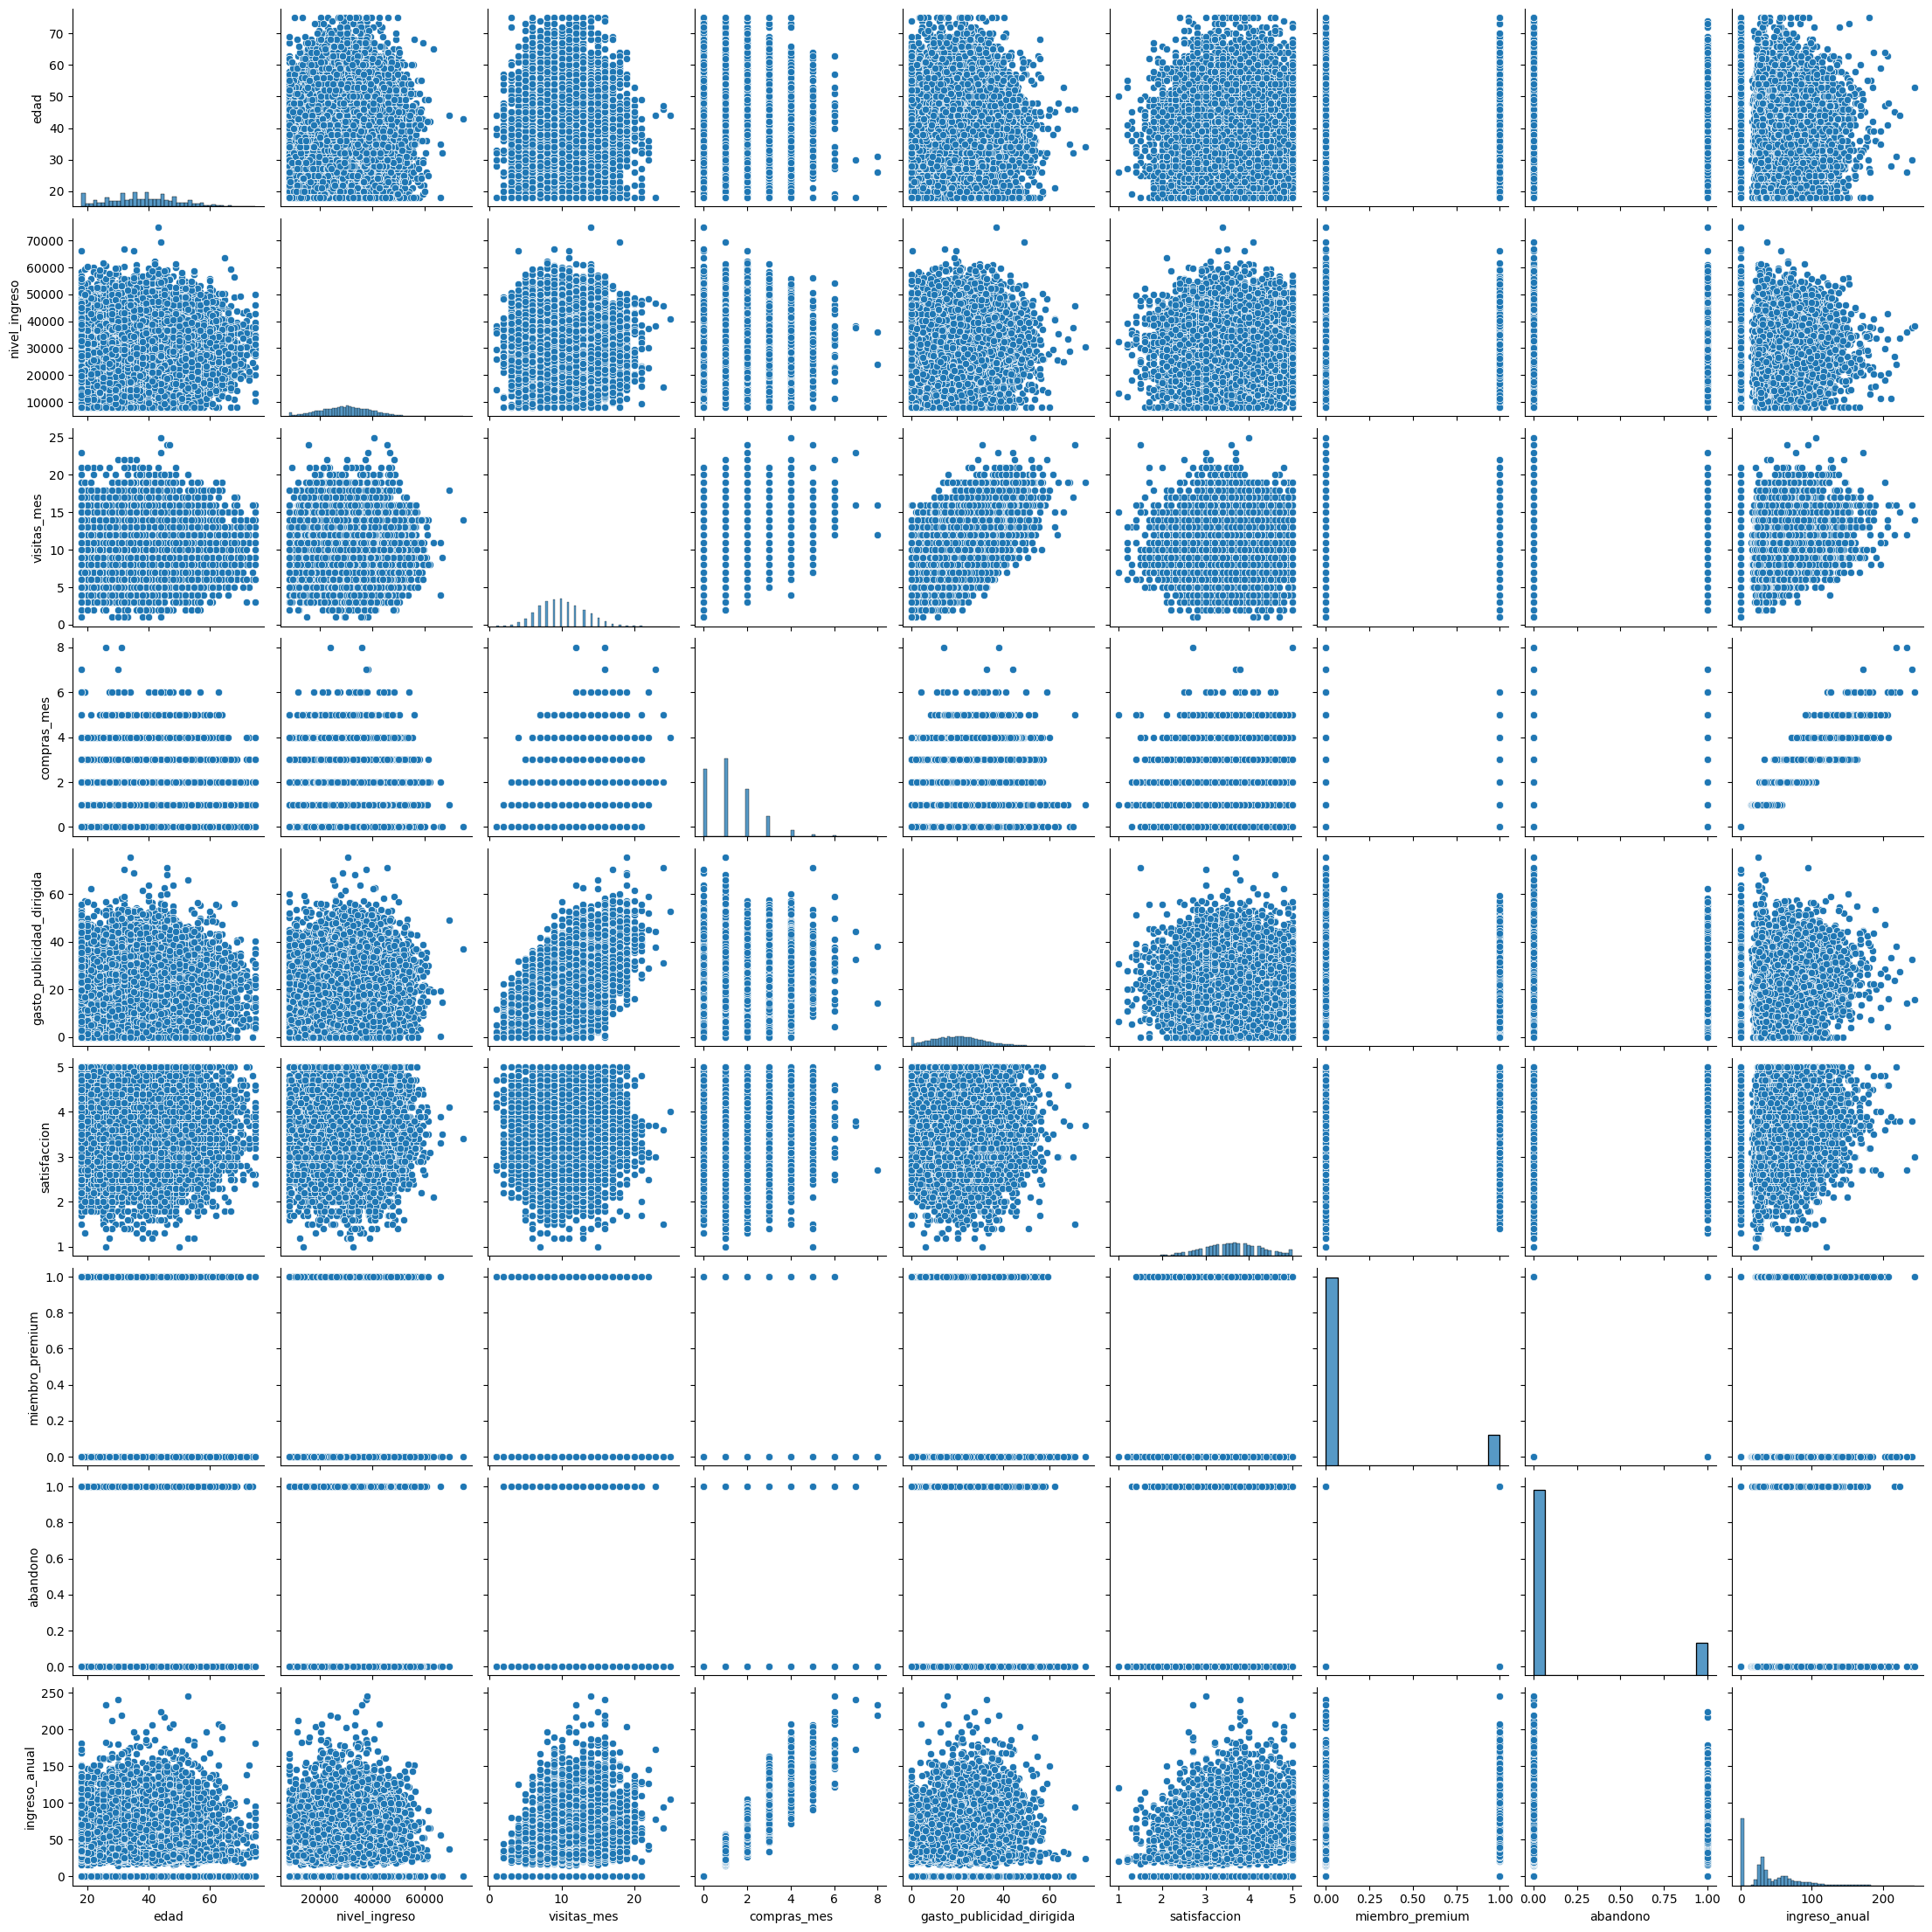

In [23]:
variables_numericas = df.select_dtypes(include='number')


sns.pairplot(variables_numericas)

plt.show()

Observación

La visualización confirma que la relación más definida se encuentra entre compras_mes e ingreso_anual. También se observan patrones positivos entre visitas_mes, gasto_publicidad_dirigida y compras_mes, aunque con mayor dispersión.

La mayoría de las demás combinaciones no muestran patrones visuales fuertes.

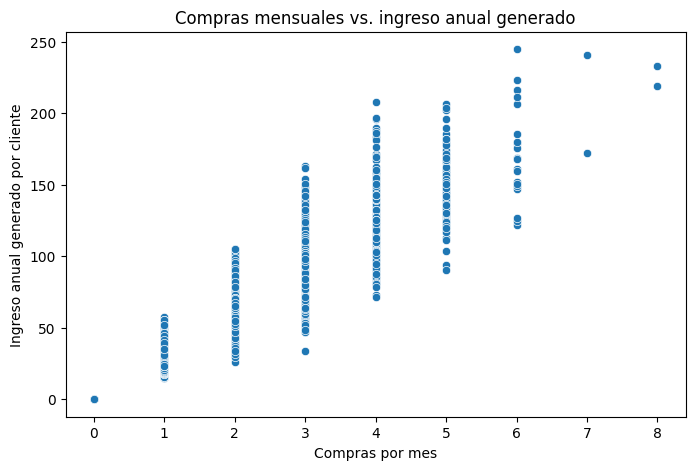

In [24]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='compras_mes',
    y='ingreso_anual',
    data=df
)

plt.title('Compras mensuales vs. ingreso anual generado')
plt.xlabel('Compras por mes')
plt.ylabel('Ingreso anual generado por cliente')

plt.show()

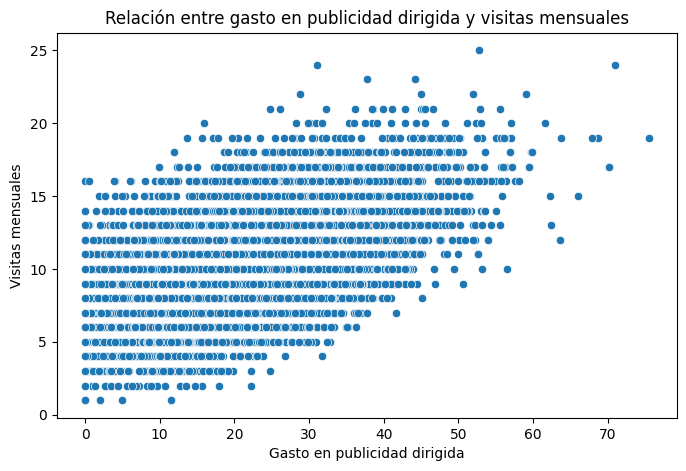

In [25]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='gasto_publicidad_dirigida',
    y='visitas_mes',
    data=df
)

plt.title('Relación entre gasto en publicidad dirigida y visitas mensuales')
plt.xlabel('Gasto en publicidad dirigida')
plt.ylabel('Visitas mensuales')

plt.show()

Observaciones de los scatterplots

Compras mensuales vs. ingreso anual generado

Se observa una relación positiva muy fuerte: a medida que aumenta la frecuencia de compra, también aumenta el ingreso anual generado por cliente. El patrón visual es consistente con la correlación previamente identificada (r = 0.97).

Aunque existe cierta variabilidad dentro de cada nivel de compra, la tendencia ascendente es claramente visible. Esto refuerza la importancia de la frecuencia de compra como indicador del valor económico del cliente.

Gasto en publicidad dirigida vs. visitas mensuales

Se observa una relación positiva moderada entre la inversión en publicidad dirigida y el número de visitas mensuales, consistente con la correlación observada (r = 0.58).

La mayor dispersión indica que la inversión publicitaria no explica por sí sola el comportamiento de las visitas y que probablemente intervienen otros factores.

Insight de negocio

Las visualizaciones refuerzan dos patrones relevantes: la frecuencia de compra está estrechamente asociada con los ingresos generados, mientras que la publicidad dirigida está asociada con un mayor nivel de tráfico, aunque con una relación menos directa.

In [26]:
correlacion_pearson = df['compras_mes'].corr(
    df['ingreso_anual'],
    method='pearson'
)

correlacion_spearman = df['compras_mes'].corr(
    df['ingreso_anual'],
    method='spearman'
)

print("Correlación de Pearson:", correlacion_pearson)
print("Correlación de Spearman:", correlacion_spearman)


Correlación de Pearson: 0.9671485435708559
Correlación de Spearman: 0.967482492032673


In [27]:
correlacion_pearson = df['gasto_publicidad_dirigida'].corr(
    df['visitas_mes'],
    method='pearson'
)

correlacion_spearman = df['gasto_publicidad_dirigida'].corr(
    df['visitas_mes'],
    method='spearman'
)

print("Correlación de Pearson:", correlacion_pearson)
print("Correlación de Spearman:", correlacion_spearman)


Correlación de Pearson: 0.5789472719412829
Correlación de Spearman: 0.5592673242622609


Validación de las correlaciones

Para evaluar la consistencia de las relaciones identificadas, se compararon los coeficientes de Pearson y Spearman.

Compras mensuales vs. ingreso anual generado

Pearson: 0.9671
Spearman: 0.9675

Ambos coeficientes muestran una asociación positiva muy fuerte y prácticamente idéntica. Esto indica que la relación observada es consistente tanto desde una perspectiva lineal como monotónica.

Gasto en publicidad dirigida vs. visitas mensuales

Pearson: 0.5789
Spearman: 0.5593

Ambos métodos muestran una asociación positiva moderada. La cercanía entre los coeficientes indica que el patrón identificado es relativamente consistente y no depende exclusivamente del método de correlación utilizado.

Conclusión

Los resultados de Pearson y Spearman son similares para ambas relaciones, lo que aporta mayor consistencia a los patrones identificados durante el análisis exploratorio.

In [28]:
from scipy.stats import pointbiserialr

corr1, p1 = pointbiserialr(df['abandono'], df['satisfaccion'])
corr2, p2 = pointbiserialr(df['miembro_premium'], df['compras_mes'])

print("abandono vs satisfaccion:", corr1)
print("miembro_premium vs compras_mes:", corr2)

abandono vs satisfaccion: -0.02383256067380407
miembro_premium vs compras_mes: 0.0034305369677068813


Análisis de correlación punto-biserial

Se utilizó la correlación punto-biserial para evaluar asociaciones entre variables binarias y numéricas.

Abandono vs. satisfacción

Correlación punto-biserial: -0.0238

La asociación es negativa y prácticamente nula. Aunque el signo indica que una mayor satisfacción está asociada con un abandono ligeramente menor, la magnitud del coeficiente muestra que la satisfacción por sí sola no presenta una relación relevante con el abandono en este conjunto de datos.

Membresía Premium vs. compras mensuales

Correlación punto-biserial: 0.0034

La asociación observada es positiva pero prácticamente inexistente, lo que indica que pertenecer al programa Premium no está asociado de forma relevante con una mayor frecuencia de compra en este dataset.

Insight de negocio

Estos resultados sugieren que ni la satisfacción ni la membresía Premium, consideradas individualmente, explican de manera importante el comportamiento de abandono o la frecuencia de compra. Será necesario considerar otras variables o combinaciones de factores para comprender mejor estos comportamientos.

In [29]:
def cramers_v(x, y):
    tabla = pd.crosstab(x, y)

    chi2 = stats.chi2_contingency(tabla)[0]
    n = tabla.sum().sum()

    r, k = tabla.shape

    return np.sqrt(chi2 / (n * (min(r, k) - 1)))# Función para calcular V de Cramér


In [30]:
v_cramer_1 = cramers_v(df['tipo_dispositivo'], df['region'])
v_cramer_2 = cramers_v(df['miembro_premium'], df['abandono'])

print("V de Cramér (tipo_dispositivo vs region):", v_cramer_1)
print("V de Cramér (miembro_premium vs abandono):", v_cramer_2)# Aplicar V de Cramér en variables relevantes



V de Cramér (tipo_dispositivo vs region): 0.012378338407739397
V de Cramér (miembro_premium vs abandono): 0.12021874609740511




Análisis de asociación con V de Cramér

Se utilizó V de Cramér para evaluar la intensidad de la asociación entre variables categóricas/binarias.

Tipo de dispositivo vs. región

V de Cramér: 0.0124

La asociación es prácticamente nula, lo que indica que el tipo de dispositivo utilizado por los clientes no presenta una relación relevante con la región en este conjunto de datos.

Membresía Premium vs. abandono

V de Cramér: 0.1202

Se observa una asociación débil entre la membresía Premium y el abandono. Aunque existe cierta relación entre ambas variables, su magnitud es baja, por lo que la membresía Premium por sí sola no parece ser un indicador fuerte del abandono.

Insight de negocio

Los resultados sugieren que la región no determina de manera relevante el tipo de dispositivo utilizado y que la membresía Premium tiene una asociación limitada con el abandono.


Aquí hay una **corrección importante**. El hallazgo está bien estructurado, pero la interpretación confunde `ingreso_anual` con `nivel_ingreso`.

En tu dataset:

* `nivel_ingreso` = ingreso estimado **del cliente**.
* `ingreso_anual` = ingreso que **el cliente genera para Nova Retail**.

Por eso esta frase es incorrecta:

> “Los usuarios con mayores ingresos tienden a realizar una mayor cantidad de compras mensuales.”

No estamos analizando cuánto dinero gana el cliente. Estamos analizando cuánto **revenue genera para Nova Retail**.

Y por la misma razón, tampoco recomendaría campañas para “clientes con mayores ingresos” basándonos en esta correlación.

Yo convertiría el Hallazgo 1 en:

### Hallazgo 1 — La frecuencia de compra está fuertemente asociada con el valor generado por cliente

**Evidencia visual:**
El *scatterplot* entre `compras_mes` e `ingreso_anual` muestra una tendencia ascendente claramente definida. Los puntos siguen un patrón consistente, evidenciando una relación positiva fuerte entre ambas variables.

**Evidencia numérica:**

* Pearson: **0.9671**
* Spearman: **0.9675**

**Interpretación:**
Existe una asociación positiva muy fuerte entre la frecuencia de compra y el ingreso anual generado para Nova Retail. Los clientes que realizan más compras mensuales tienden a generar mayores ingresos para la empresa. La similitud entre Pearson y Spearman muestra que este patrón es consistente tanto desde una perspectiva lineal como monotónica.

**No podemos afirmar:**
La correlación no demuestra que aumentar por sí solo el número de compras cause necesariamente un determinado incremento en ingresos. Otros factores, como el valor de cada compra, las categorías adquiridas, promociones o descuentos, también pueden influir en el ingreso generado.

**Implicación de negocio:**
Nova Retail podría identificar clientes con **baja o media frecuencia de compra** y analizar estrategias para aumentar la recurrencia, como promociones personalizadas, programas de fidelización o recomendaciones de productos. También sería útil estudiar a los clientes de alta frecuencia para identificar patrones que puedan apoyar estrategias de retención.


Hallazgo 2 — La publicidad dirigida está asociada con una mayor frecuencia de visitas

Evidencia visual:
El scatterplot entre gasto_publicidad_dirigida y visitas_mes presenta una tendencia positiva moderada. Los puntos muestran una dispersión media, aunque mantienen un patrón ascendente.

Evidencia numérica:

Pearson: 0.5789
Spearman: 0.5593

Interpretación:
Existe una asociación positiva moderada entre la inversión en publicidad dirigida y las visitas mensuales. Los clientes asociados con un mayor gasto publicitario tienden a registrar una mayor frecuencia de visitas.

No podemos afirmar:
No se puede concluir que la publicidad sea la causa directa del aumento de visitas. Otros factores, como promociones, estacionalidad, redes sociales o comportamiento del mercado, también podrían influir en el tráfico.

Implicación de negocio:
La relación identificada justifica analizar con mayor profundidad el rendimiento de la publicidad dirigida. Nova Retail debería evaluar si el mayor tráfico asociado con la inversión publicitaria se convierte posteriormente en compras e ingresos, además de comparar el desempeño de diferentes campañas o canales.


Limitaciones

Las asociaciones identificadas mediante correlación no implican causalidad.
Varias de las relaciones observadas son moderadas o débiles y, por sí solas, tienen capacidad explicativa limitada.
Variables como edad, satisfaccion y nivel_ingreso presentan asociaciones débiles en el análisis realizado.
El análisis está limitado a las variables disponibles en el dataset; otros factores relacionados con comportamiento, marketing o historial del cliente podrían influir en los resultados.
La presencia de posibles valores atípicos puede afectar algunas métricas y requiere evaluación adicional.
Próximos pasos

1. Profundizar en la segmentación de clientes

Comparar comportamiento, compras e ingresos por región.
Analizar diferencias según tipo de dispositivo.
Identificar perfiles de clientes de alto valor y alta frecuencia de compra.

2. Profundizar en abandono y retención

Evaluar múltiples variables conjuntamente para identificar factores asociados con el abandono.
Explorar posteriormente modelos predictivos de churn si el objetivo del negocio requiere anticipar clientes en riesgo.

3. Evaluar la efectividad de marketing

Analizar si el tráfico asociado con publicidad dirigida se convierte en compras e ingresos.
Incorporar información temporal y por campaña.
Calcular métricas de rendimiento como conversión y ROI cuando estén disponibles los datos necesarios.